# Empirical Distributions

Notebooks 01–03 described parametric population models, empirical moments and inferential uncertainty. This notebook asks what can be learned directly from a finite sample without specifying its entire distribution. Histograms, density estimates and the empirical CDF lead to QQ plots, which reconnect empirical observations with parametric assumptions.

I use simulations from known populations so that each empirical description can be compared with its target. Notebook 05 applies distributional descriptions to financial returns and losses.

Throughout these examples, $X_1,\ldots,X_n\overset{\mathrm{iid}}{\sim}F(\cdot;\theta)$ is a simplifying sampling framework. Financial returns need not be fully IID because dependence over time can matter. The time-series notebooks address that distinction.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})
from finstats.nonparametric import empirical_cdf, empirical_quantile, qq_data

## 1. From Population to Observed Sample

The population distribution is not directly observed. The values $x_1,\ldots,x_n$ are one finite realization, whose empirical shape and moments generally differ from population quantities. Simulation makes this distinction visible because the generating population is known. With actual data, a proposed parametric distribution remains an assumption.

Nonparametric methods avoid choosing a distributional family, but still face finite-sample uncertainty. Their smoothing and quantile conventions also need to be specified.

## 2. Empirical Distribution

### Histogram

A histogram divides the observation range into bins. If a bin has width $\Delta$ and contains $n_j$ observations, its density height is $n_j/(n\Delta)$. The rectangle's area is the empirical fraction $n_j/n$. Its shape depends on the bin boundaries and widths.

### Kernel density estimation

The course writes a symmetric kernel density as $K(y;b)$, where $b>0$ is its bandwidth. A Gaussian kernel is
$$K(y;b)=\frac1{b\sqrt{2\pi}}\exp\left(-\frac{y^2}{2b^2}\right).$$
Placing a kernel at each observation and averaging gives
$$\hat f_b(y)=\frac1n\sum_{i=1}^n K(y-x_i;b)
=\frac1{nb}\sum_{i=1}^n K_0\left(\frac{y-x_i}{b}\right),$$
where $K_0$ is a unit-bandwidth kernel. The kernel integrates to one, so the estimate is also a density.

A smaller bandwidth reduces smoothing bias but increases variability. A larger bandwidth reduces local variability while potentially obscuring population features. This is the bias–variance trade-off in a density estimate, rather than a choice between different generating populations.

For illustration, I retain 250 IID observations from $0.6N(-1,0.5^2)+0.4N(1.5,0.7^2)$ with seed 406. The small/default/large bandwidth comparison uses 0.1, 1 and 100 times SciPy's Scott factor. This default differs from R's rule. The known density and histogram provide reference points.

Multiplier 0.1: bandwidth 0.0440
Multiplier 1: bandwidth 0.4401
Multiplier 100: bandwidth 44.0143


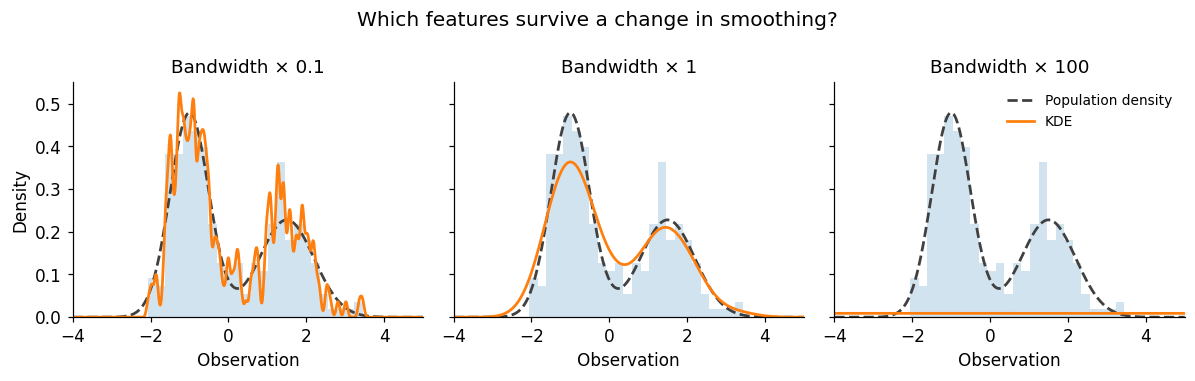

In [2]:
rng_kde = np.random.default_rng(406)
components = rng_kde.random(250) < .6
mixture_sample = rng_kde.normal(np.where(components, -1, 1.5), np.where(components, .5, .7))
kde_grid = np.linspace(-4, 5, 801)
mixture_density = .6*stats.norm.pdf(kde_grid, loc=-1, scale=.5)+.4*stats.norm.pdf(kde_grid, loc=1.5, scale=.7)
default_kde = stats.gaussian_kde(mixture_sample)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharex=True, sharey=True)
for ax, multiplier in zip(axes, (.1, 1, 100)):
    kde = stats.gaussian_kde(mixture_sample, bw_method=default_kde.factor*multiplier)
    ax.hist(mixture_sample, bins=25, density=True, alpha=.2)
    ax.plot(kde_grid, mixture_density, "--", color="0.25", label="Population density")
    ax.plot(kde_grid, kde(kde_grid), color="C1", label="KDE")
    ax.set(xlabel="Observation", title=f"Bandwidth × {multiplier:g}", xlim=(-4, 5))
    print(f"Multiplier {multiplier:g}: bandwidth {np.sqrt(kde.covariance[0,0]):.4f}")
axes[0].set_ylabel("Density")
axes[-1].legend(fontsize=9)
fig.suptitle("Which features survive a change in smoothing?")
fig.tight_layout()
plt.show()

The smallest bandwidth produces peaks tied closely to individual observations. The largest smooths away both population groups. Neither local fluctuations nor an exceptionally smooth curve should be treated as evidence of the true shape. A KDE also does not reveal unobserved extreme outcomes reliably.

## 3. Empirical Cumulative Distribution

### Empirical cumulative distribution function

The ECDF counts the fraction of observations at or below a threshold:
$$\hat F_n(x)=\frac1n\sum_{i=1}^n I(x_i\le x).$$
It is right-continuous and combines jumps at tied observations. Even for a continuous population, its empirical distribution places mass on observed values.

Under IID sampling, at a fixed $x$,
$$E[\hat F_n(x)]=F(x),\qquad \operatorname{Var}[\hat F_n(x)]=\frac{F(x)(1-F(x))}{n}.$$
The expectation identifies its population target and the variance describes sampling uncertainty. Pointwise consistency follows as $n$ grows. These results do not require a finite population mean, since the indicators are bounded.

### Empirical quantiles and inverse empirical CDF

The inverse ECDF gives the empirical quantile
$$\hat x_q=\inf\{x:\hat F_n(x)\ge q\}=x_{(\lceil nq\rceil)},\qquad0<q<1,$$
where $x_{(j)}$ is the $j$th ordered observation. This convention does not interpolate. The library returns the minimum and maximum for its endpoint conventions $q=0$ and $q=1$.

For illustration, I retain the course's Cauchy example at $n=5,100,1000$, with nested IID samples and seed 0. The same figure shows the ECDF and its inverse at $q=.75$, whose population quantile is one. Full sample ranges are printed because the common plotting window omits extreme observations.

n=5: full range -5.015 to 5.379, outside window: 0
n=100: full range -135.080 to 81.215, outside window: 2
n=1000: full range -808.531 to 234.208, outside window: 72


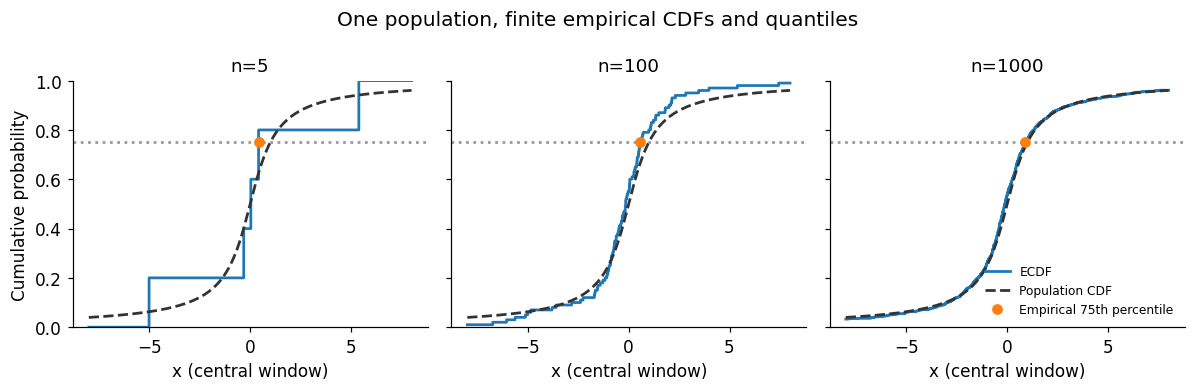

,n,Population 75th percentile,Empirical 75th percentile
0,5,1.0,0.4124
1,100,1.0,0.5731
2,1000,1.0,0.9065


In [3]:
cauchy_sample = np.random.default_rng(0).standard_t(1, size=1000)
cdf_grid = np.linspace(-8, 8, 1501)
q, true_quantile = .75, 1.
quantile_rows = []
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), sharex=True, sharey=True)
for ax, n in zip(axes, (5, 100, 1000)):
    values = cauchy_sample[:n]
    estimate = empirical_quantile(values, q)
    ax.step(cdf_grid, empirical_cdf(values)(cdf_grid), where="post", label="ECDF")
    ax.plot(cdf_grid, stats.t.cdf(cdf_grid, 1), "--", color="0.2", label="Population CDF")
    ax.axhline(q, color="0.6", linestyle=":")
    ax.plot([estimate], [q], "o", color="C1", label="Empirical 75th percentile")
    ax.set(xlabel="x (central window)", title=f"n={n}", ylim=(0, 1))
    quantile_rows.append([n, true_quantile, estimate])
    print(f"n={n}: full range {values.min():.3f} to {values.max():.3f}, outside window: {np.sum(np.abs(values)>8)}")
axes[0].set_ylabel("Cumulative probability")
axes[-1].legend(fontsize=8, loc="lower right")
fig.suptitle("One population, finite empirical CDFs and quantiles")
fig.tight_layout()
plt.show()
display(pd.DataFrame(quantile_rows, columns=["n", "Population 75th percentile", "Empirical 75th percentile"]).round(4))

The Cauchy population has no finite mean, but its CDF and quantiles remain well defined. A larger sample can describe those population properties more closely, even when sample extremes remain large.

## 4. Quantile-Quantile Plots

A QQ plot compares empirical quantiles with theoretical quantiles from a candidate parametric distribution. For $q_i=(i-.5)/n$, I plot
$$\left(F_0^{-1}(q_i),x_{(i)}\right),\qquad i=1,\ldots,n.$$
When candidate and population agree, the points fluctuate around the identity line. Systematic curvature can indicate a shape difference, while extreme order statistics are especially variable in finite samples.

The candidate need not be Gaussian. Any distribution with a quantile function can be used. This makes QQ plots a link between an empirical description and parametric distributional assumptions.

For illustration, I generate 1000 IID $N(0,1)$ observations with seed 408 and compare prefixes of size 20 and 1000 against Gaussian, Student-$t_5$ and Laplace candidates. All candidates have zero mean and unit variance, and their parameters are fixed, not fitted. The comparison isolates shape and finite-sample uncertainty.

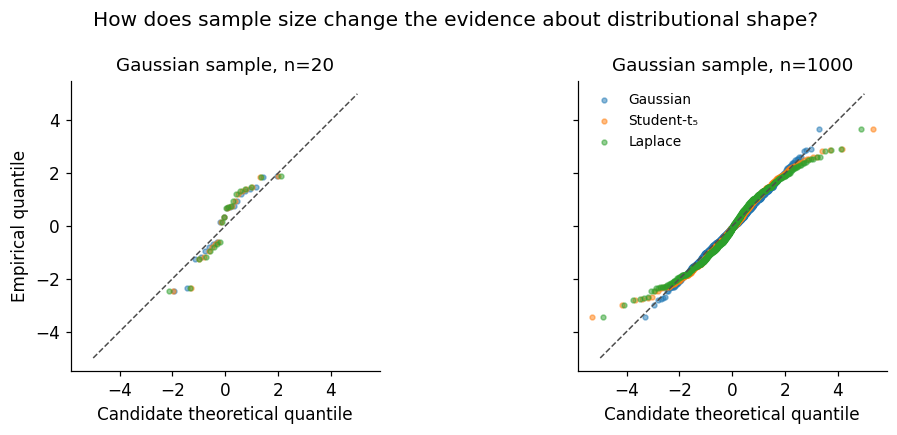

In [4]:
gaussian_sample = np.random.default_rng(408).normal(size=1000)
references = {"Gaussian": stats.norm(), "Student-t₅": stats.t(5, scale=np.sqrt(3/5)),
              "Laplace": stats.laplace(scale=1/np.sqrt(2))}
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
for ax, n in zip(axes, (20, 1000)):
    for name, reference in references.items():
        theoretical, empirical = qq_data(gaussian_sample[:n], reference)
        ax.scatter(theoretical, empirical, s=10, alpha=.5, label=name)
    ax.plot([-5, 5], [-5, 5], "--", color="0.3", linewidth=1)
    ax.set(xlabel="Candidate theoretical quantile", title=f"Gaussian sample, n={n}", aspect="equal")
axes[0].set_ylabel("Empirical quantile")
axes[-1].legend(fontsize=9)
fig.suptitle("How does sample size change the evidence about distributional shape?")
fig.tight_layout()
plt.show()

With a small sample, several candidate distributions may appear plausible because their central quantiles overlap and few observations describe the tails. More observations make systematic shape differences easier to distinguish, although tail quantiles still fluctuate.

These plots are descriptive comparisons. They do not define a formal goodness-of-fit criterion or establish that a candidate fits better. The generating distribution is known here only because the data were simulated. With observed data, empirical and parametric descriptions remain subject to sampling uncertainty.